In [1]:
from tifffile import imread

from matplotlib import pyplot as plt

import numpy as np

from skimage.morphology import h_maxima

In [3]:
image = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/Denoised/100tp_561-100-50ms-1000g_4_conf561_merged.tif')

In [7]:
denoised_img = image[:, 0]
raw_img = image[:, 1]

In [5]:
mask = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/ROIs/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_4_conf561_merged_ROI1-5.tif')

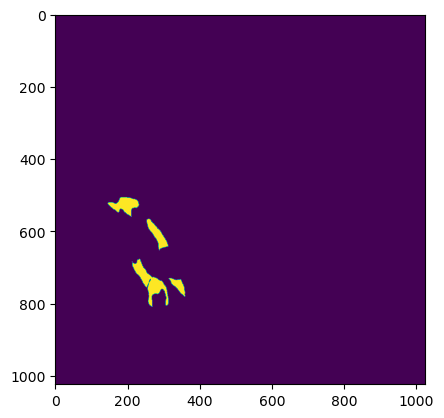

In [16]:
plt.imshow(mask > 0)

In [13]:
# Mask out foreground (mask > 0) --> go from instance segmentation to semantic segmentation (fg vs bg)
masked_cells = denoised_img * (mask > 0)

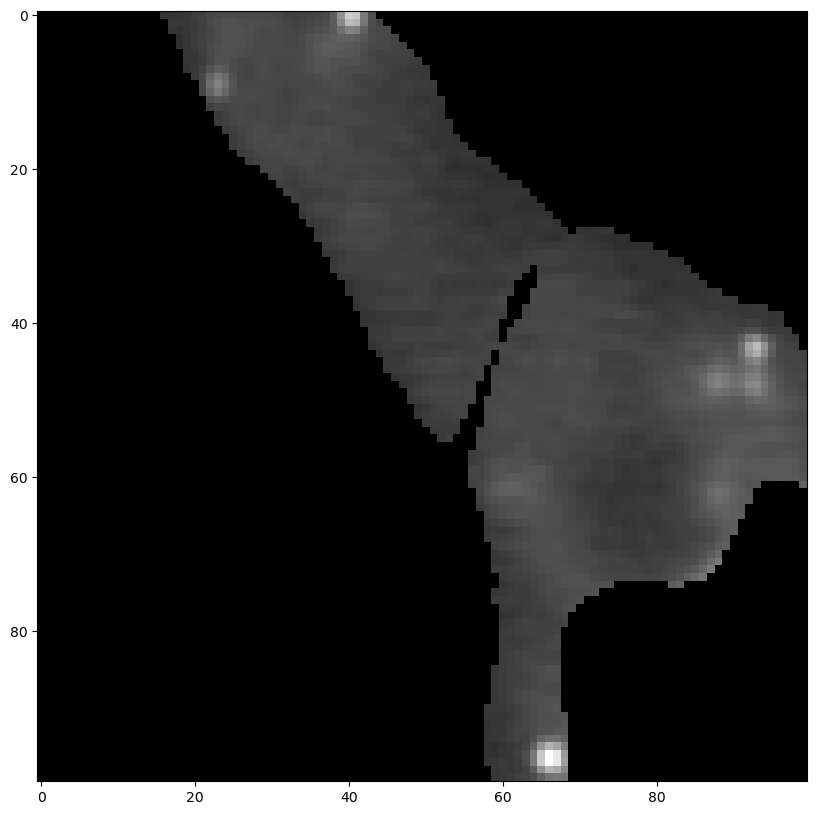

In [42]:
plt.figure(figsize=(10,10))
plt.imshow(masked_cells[0, 700:800,200:300], cmap='gray')

In [17]:
from skimage.morphology import disk

In [84]:
spots = h_maxima(image=denoised_img[0, 700:800,200:300], footprint=disk(1), h=int(np.std(denoised_img[0, mask > 0])))

In [85]:
from matplotlib.colors import ListedColormap
spot_cmap = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 1]])

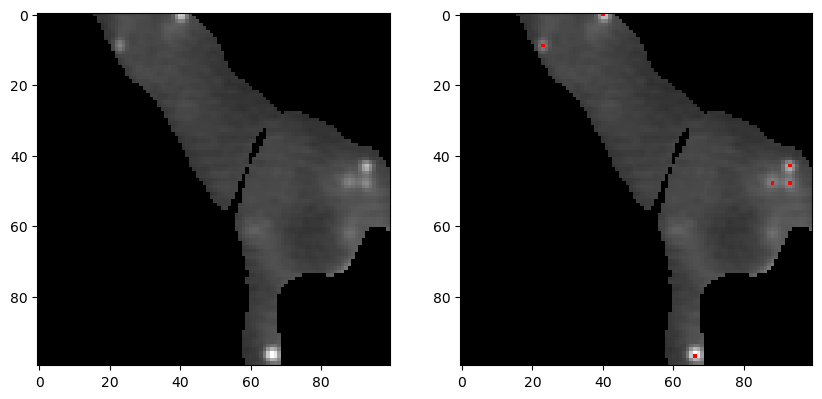

In [86]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(masked_cells[0, 700:800,200:300], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(masked_cells[0, 700:800,200:300], cmap='gray')
plt.imshow(spots * (mask[700:800, 200:300] > 0), cmap=spot_cmap)